# Quantum Reservoir Computing

In [38]:
from __future__ import annotations

import math
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import pandas as pd
from datasets import load_dataset

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

import torch
import torch.nn as nn

import perceval as pcvl

# Merlin (required)
from merlin.pcvl_pytorch.locirc_to_tensor import CircuitConverter

In [39]:
@dataclass
class CFG:
    seed: int = 7
    device: str = "cpu"

    # task
    seq_len: int = 30
    horizon: int = 6
    train_frac: float = 0.75
    eps: float = 1e-8

    # PCA
    pca_dim: int = 32

    # photonic reservoir
    m_modes: int = 10            # number of optical modes
    layers: int = 2              # fixed mixing depth
    input_scale: float = 0.35    # phase scale for input encoding
    fb_scale: float = 0.20       # phase scale for feedback contribution
    state_leak: float = 0.50     # leaky integration for reservoir state
    fb_leak: float = 0.50        # leaky integration for feedback phases
    fb_strength: float = 0.80    # main feedback strength gamma

    # feature construction
    use_pairwise: bool = True    # add pairwise coincidence-like features p_i p_j
    pairwise_max: int = 36       # cap pairwise features (for speed) by selecting first K pairs

    # readout
    ridge_alpha: float = 1e-2    # L2 regularisation for ridge

cfg = CFG()
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

device = torch.device(cfg.device)
print("device:", device)

fb_budget = 4  # number of phases to update each step (<= cfg.m_modes)
fb_idx = torch.tensor(
    np.random.choice(cfg.m_modes, fb_budget, replace=False),
    device=device
)
fb_mask = torch.zeros(cfg.m_modes, device=device)
fb_mask[fb_idx] = 1.0

device: cpu


In [40]:
def load_level1_df() -> pd.DataFrame:
    ds = load_dataset(
        "Quandela/Challenge_Swaptions",
        data_files="level-1_Future_prediction/train.csv",
        split="train",
    )
    df = ds.to_pandas()
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
    df = df.sort_values("Date").reset_index(drop=True)
    return df

def split_time_ordered(X: np.ndarray, train_frac: float) -> Tuple[np.ndarray, np.ndarray]:
    n = X.shape[0]
    n_train = int(math.floor(train_frac * n))
    return X[:n_train], X[n_train:]

def make_windows(X: np.ndarray, seq_len: int, horizon: int) -> Tuple[np.ndarray, np.ndarray]:
    T, D = X.shape
    N = T - (seq_len + horizon) + 1
    if N <= 0:
        raise ValueError(f"Not enough rows T={T} for seq_len={seq_len} + horizon={horizon}")
    X_in = np.zeros((N, seq_len, D), dtype=np.float32)
    Y = np.zeros((N, horizon, D), dtype=np.float32)
    for i in range(N):
        X_in[i] = X[i : i + seq_len]
        Y[i] = X[i + seq_len : i + seq_len + horizon]
    return X_in, Y

In [41]:
df = load_level1_df()
feature_cols = [c for c in df.columns if c != "Date"]

X_vol = df[feature_cols].to_numpy(dtype=np.float32)         # (T, 224)
X_log = np.log(X_vol + cfg.eps).astype(np.float32)          # log-vol

X_train_log, X_val_log = split_time_ordered(X_log, cfg.train_frac)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train_log)
X_val_std = scaler.transform(X_val_log)

pca_dim = min(cfg.pca_dim, X_train_std.shape[1])
pca = PCA(n_components=pca_dim, random_state=cfg.seed, whiten=True)
Z_train = pca.fit_transform(X_train_std).astype(np.float32) # (Ttrain, pca_dim)
Z_val = pca.transform(X_val_std).astype(np.float32)

Xtr_win, Ytr_win = make_windows(Z_train, cfg.seq_len, cfg.horizon)
Xva_win, Yva_win = make_windows(Z_val, cfg.seq_len, cfg.horizon)

print("train windows:", Xtr_win.shape, Ytr_win.shape)
print("val windows  :", Xva_win.shape, Yva_win.shape)

train windows: (335, 30, 32) (335, 6, 32)
val windows  : (89, 30, 32) (89, 6, 32)


In [42]:
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mape(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> float:
    return float(np.mean(np.abs(a - b) / (np.abs(b) + eps)))

def invert_to_vol(Z_pca: np.ndarray, pca: PCA, scaler: StandardScaler, eps: float) -> np.ndarray:
    flat = Z_pca.reshape(-1, Z_pca.shape[-1])
    X_std = pca.inverse_transform(flat)
    X_log = scaler.inverse_transform(X_std)
    X_vol = np.exp(X_log) - eps
    return X_vol.reshape(*Z_pca.shape[:-1], X_vol.shape[-1])

In [43]:
def add_mixer(c: pcvl.Circuit, m: int):
    # A simple, hardware-friendly fixed mixer: two rounds of nearest-neighbour BS
    for i in range(0, m - 1, 2):
        c.add((i, i + 1), pcvl.BS())
    for i in range(1, m - 1, 2):
        c.add((i, i + 1), pcvl.BS())

def build_lo_reservoir_circuit(m: int, layers: int):
    """
    Fixed mixing + programmable phase layers.
    Parameters:
      in00..in{m-1}  : input encoding
      fb00..fb{m-1}  : feedback (stateful) phases
    """
    c = pcvl.Circuit(m)
    in_params = [pcvl.P(f"in{i:02d}") for i in range(m)]
    fb_params = [pcvl.P(f"fb{i:02d}") for i in range(m)]

    # initial mixing
    add_mixer(c, m)

    # layered structure
    for _ in range(layers):
        # input injection (programmable)
        for i in range(m):
            c.add(i, pcvl.PS(in_params[i]))

        # feedback phases (programmable)
        for i in range(m):
            c.add(i, pcvl.PS(fb_params[i]))

        # fixed mixing
        add_mixer(c, m)

    return c

circuit = build_lo_reservoir_circuit(cfg.m_modes, cfg.layers)
converter = CircuitConverter(circuit, input_specs=["in", "fb"])
print("circuit modes:", circuit.m)

circuit modes: 10


In [44]:
def wrap_to_pi(x: torch.Tensor) -> torch.Tensor:
    # map to (-pi, pi]
    return (x + math.pi) % (2 * math.pi) - math.pi

def make_pair_indices(m: int, K: int):
    pairs = []
    for i in range(m):
        for j in range(i + 1, m):
            pairs.append((i, j))
    return pairs[:K]

pair_idx = make_pair_indices(cfg.m_modes, cfg.pairwise_max)

def two_photon_coinc_features(U, a=0, b=1, max_pairs=36):
    """
    U: (B, m, m) complex torch tensor
    returns: (B, K) where K=max_pairs coincidence probs for first K output pairs (i<j)
    """
    B, m, _ = U.shape
    feats = []
    cnt = 0
    for i in range(m):
        for j in range(i+1, m):
            amp = U[:, i, a] * U[:, j, b] + U[:, i, b] * U[:, j, a]
            feats.append((amp.abs()**2).unsqueeze(1))
            cnt += 1
            if cnt >= max_pairs:
                return torch.cat(feats, dim=1)
    return torch.cat(feats, dim=1)

class PhotonicFeedbackReservoir(nn.Module):
    def __init__(self, d_in: int, m: int, use_pairwise: bool, pair_idx):
        super().__init__()
        self.d_in = d_in
        self.m = m
        self.use_pairwise = use_pairwise
        self.pair_idx = pair_idx

        # fixed random input mask (RC-style): d_in -> m phases
        W_in = 0.5 * torch.randn(d_in, m)
        self.register_buffer("W_in", W_in)

        # feature dim: m probs + (optional) pairwise products
        self.f_dim = m + (len(pair_idx) if use_pairwise else 0)

        # fixed random feedback map: features -> m phase updates
        W_fb = 0.5 * torch.randn(self.f_dim, m)
        self.register_buffer("W_fb", W_fb)

    # def features_from_probs(self, p: torch.Tensor) -> torch.Tensor:
    #     # p: (B, m)
    #     if not self.use_pairwise:
    #         return p
    #     # pairwise products p_i p_j
    #     B = p.shape[0]
    #     pp = torch.empty(B, len(self.pair_idx), device=p.device, dtype=p.dtype)
    #     for k, (i, j) in enumerate(self.pair_idx):
    #         pp[:, k] = p[:, i] * p[:, j]
    #     return torch.cat([p, pp], dim=-1)  # (B, f_dim)

    #####


    #####

    def forward_states(self, X: torch.Tensor, *, input_scale: float, fb_scale: float,
                       state_leak: float, fb_leak: float, fb_strength: float) -> torch.Tensor:
        """
        X: (B, L, d_in)
        returns final reservoir state s_L: (B, f_dim)
        """
        B, L, d = X.shape
        assert d == self.d_in

        s = torch.zeros(B, self.f_dim, device=X.device)
        fb = torch.zeros(B, self.m, device=X.device)

        for t in range(L):
            x_t = X[:, t, :]  # (B, d_in)

            # input phases (fixed random mask)
            in_phase = input_scale * torch.tanh(x_t @ self.W_in) * math.pi   # (B, m)
            fb_phase = fb_scale * fb                                      # (B, m)

            # Merlin unitary: U(B,m,m)
            U = converter.to_tensor(in_phase, fb_phase)

            # # single-photon "threshold" readout: p_i = |U_{i0}|^2
            # p = (U[:, :, 0].abs() ** 2).clamp_min(1e-12)  # (B, m)

            # # reservoir features
            # z = self.features_from_probs(p)               # (B, f_dim)

            #####

            # single-photon intensities (optional to keep)
            p = (U[:, :, 0].abs() ** 2).clamp_min(1e-12)  # (B, m)

            # 2-photon coincidences (adds nonlinearity)
            c2 = two_photon_coinc_features(U, a=0, b=1, max_pairs=cfg.pairwise_max)  # (B, K)

            # build reservoir feature z
            z = torch.cat([p, c2], dim=-1)

            #####

            # leaky reservoir state
            s = (1.0 - state_leak) * s + state_leak * z

            # measurement-conditioned feedback update (budgeted structured update)
            # Here: fb <- leaky + gamma * (z W_fb), wrapped to (-pi,pi]
            delta = fb_strength * (z @ self.W_fb)
            delta = delta * fb_mask[None, :]   # budgeted update
            fb = (1.0 - fb_leak) * fb + fb_leak * delta
            fb = wrap_to_pi(fb)

        return s

reservoir = PhotonicFeedbackReservoir(d_in=pca_dim, m=cfg.m_modes,
                                      use_pairwise=cfg.use_pairwise, pair_idx=pair_idx).to(device)

print("feature dim:", reservoir.f_dim)

feature dim: 46


In [45]:
@torch.no_grad()
def compute_reservoir_features(X_win: np.ndarray, batch_size: int = 64) -> np.ndarray:
    """
    X_win: (N, L, d_in) numpy
    returns R: (N, f_dim) numpy
    """
    reservoir.eval()
    N = X_win.shape[0]
    out = np.zeros((N, reservoir.f_dim), dtype=np.float32)

    for i in range(0, N, batch_size):
        xb = torch.from_numpy(X_win[i:i+batch_size]).to(device)
        sb = reservoir.forward_states(
            xb,
            input_scale=cfg.input_scale,
            fb_scale=cfg.fb_scale,
            state_leak=cfg.state_leak,
            fb_leak=cfg.fb_leak,
            fb_strength=cfg.fb_strength,
        )
        out[i:i+batch_size] = sb.cpu().numpy().astype(np.float32)

    return out

R_tr = compute_reservoir_features(Xtr_win, batch_size=64)
R_va = compute_reservoir_features(Xva_win, batch_size=64)

print("R_tr:", R_tr.shape, "R_va:", R_va.shape)

R_tr: (335, 46) R_va: (89, 46)


In [46]:
from sklearn.linear_model import Ridge

def residual_targets(X_win: np.ndarray, Y_win: np.ndarray):
    last = X_win[:, -1, :]            # (N, D)
    Y_res = Y_win - last[:, None, :]  # (N, H, D)
    return last, Y_res

####

tr_true_vol = invert_to_vol(Ytr_win, pca=pca, scaler=scaler, eps=cfg.eps)
va_true_vol = invert_to_vol(Yva_win, pca=pca, scaler=scaler, eps=cfg.eps)

#####

# Residual targets
last_tr, Ytr_res = residual_targets(Xtr_win, Ytr_win)
last_va, Yva_res = residual_targets(Xva_win, Yva_win)

Ytr_res_flat = Ytr_res.reshape(Ytr_res.shape[0], -1)
Yva_res_flat = Yva_res.reshape(Yva_res.shape[0], -1)

# Reservoir states
R_tr = compute_reservoir_features(Xtr_win, batch_size=64)
R_va = compute_reservoir_features(Xva_win, batch_size=64)

readout = Ridge(alpha=cfg.ridge_alpha, fit_intercept=True)
readout.fit(R_tr, Ytr_res_flat)

# Predict residuals then add persistence back
# Predict residuals then add persistence back
Ytr_res_hat = readout.predict(R_tr).astype(np.float32).reshape(Ytr_win.shape)
Ytr_hat = Ytr_res_hat + last_tr[:, None, :]
Yva_res_hat = readout.predict(R_va).astype(np.float32).reshape(Yva_win.shape)
Yva_hat = Yva_res_hat + last_va[:, None, :]

tr_pred_vol = invert_to_vol(Ytr_hat, pca=pca, scaler=scaler, eps=cfg.eps)
va_pred_vol = invert_to_vol(Yva_hat, pca=pca, scaler=scaler, eps=cfg.eps)
print("RESID-RC TRAIN RMSE:", rmse(tr_pred_vol, tr_true_vol))
print("RESID-RC TRAIN MAPE:", mape(tr_pred_vol, tr_true_vol, eps=cfg.eps))
print("RESID-RC VAL RMSE:", rmse(va_pred_vol, va_true_vol))
print("RESID-RC VAL MAPE:", mape(va_pred_vol, va_true_vol, eps=cfg.eps))

####

def eval_for_params(fb_strength: float, ridge_alpha: float) -> Tuple[float, float]:
    cfg.fb_strength = fb_strength
    cfg.ridge_alpha = ridge_alpha

    # Residual targets
    last_tr, Ytr_res = residual_targets(Xtr_win, Ytr_win)
    last_va, Yva_res = residual_targets(Xva_win, Yva_win)

    Ytr_res_flat = Ytr_res.reshape(Ytr_res.shape[0], -1)
    Yva_res_flat = Yva_res.reshape(Yva_res.shape[0], -1)

    R_tr = compute_reservoir_features(Xtr_win, batch_size=64)
    R_va = compute_reservoir_features(Xva_win, batch_size=64)

    readout = Ridge(alpha=cfg.ridge_alpha, fit_intercept=True)
    readout.fit(R_tr, Ytr_res_flat)

    Ytr_res_hat = readout.predict(R_tr).astype(np.float32).reshape(Ytr_win.shape)
    Ytr_hat = Ytr_res_hat + last_tr[:, None, :]
    Yva_res_hat = readout.predict(R_va).astype(np.float32).reshape(Yva_win.shape)
    Yva_hat = Yva_res_hat + last_va[:, None, :]

    tr_pred_vol = invert_to_vol(Ytr_hat, pca=pca, scaler=scaler, eps=cfg.eps)
    va_pred_vol = invert_to_vol(Yva_hat, pca=pca, scaler=scaler, eps=cfg.eps)
    return rmse(tr_pred_vol, tr_true_vol), mape(tr_pred_vol, tr_true_vol, eps=cfg.eps), rmse(va_pred_vol, va_true_vol), mape(va_pred_vol, va_true_vol, eps=cfg.eps)

fb_grid = [0.0, 0.1, 0.3, 1.0, 1.5, 2.5]
ridge_grid = [0.1, 0.2, 0.3, 1.0, 10.0]

best = (1e9, None, None, None)
for g in fb_grid:
    for a in ridge_grid:
        tr_rmse, tr_mape, v_rmse, v_mape = eval_for_params(g, a)
        print(f"fb_strength={g:>4} ridge={a:.0e} | train RMSE={tr_rmse:.6f} MAPE={tr_mape:.6f} | val RMSE={v_rmse:.6f} MAPE={v_mape:.6f}")
        if v_rmse < best[0]:
            best = (v_rmse, v_mape, g, a)

print("\nBEST:", {"val_RMSE": best[0], "val_MAPE": best[1], "fb_strength": best[2], "ridge_alpha": best[3]})

RESID-RC TRAIN RMSE: 0.0072249299846589565
RESID-RC TRAIN MAPE: 0.024216098710894585
RESID-RC VAL RMSE: 0.007412292528897524
RESID-RC VAL MAPE: 0.028550047427415848
fb_strength= 0.0 ridge=1e-01 | train RMSE=0.007486 MAPE=0.025207 | val RMSE=0.006712 MAPE=0.026506
fb_strength= 0.0 ridge=2e-01 | train RMSE=0.007576 MAPE=0.025515 | val RMSE=0.006627 MAPE=0.026297
fb_strength= 0.0 ridge=3e-01 | train RMSE=0.007624 MAPE=0.025679 | val RMSE=0.006592 MAPE=0.026264
fb_strength= 0.0 ridge=1e+00 | train RMSE=0.007755 MAPE=0.026115 | val RMSE=0.006570 MAPE=0.026476
fb_strength= 0.0 ridge=1e+01 | train RMSE=0.007915 MAPE=0.026638 | val RMSE=0.006679 MAPE=0.026890
fb_strength= 0.1 ridge=1e-01 | train RMSE=0.007486 MAPE=0.025202 | val RMSE=0.006719 MAPE=0.026518
fb_strength= 0.1 ridge=2e-01 | train RMSE=0.007575 MAPE=0.025508 | val RMSE=0.006632 MAPE=0.026308
fb_strength= 0.1 ridge=3e-01 | train RMSE=0.007623 MAPE=0.025672 | val RMSE=0.006597 MAPE=0.026275
fb_strength= 0.1 ridge=1e+00 | train RMSE=0

In [47]:
import numpy as np

def persistence_forecast_vol(X_win_pca: np.ndarray) -> np.ndarray:
    # predict next H = repeat last observed step in PCA space
    last = X_win_pca[:, -1, :]                 # (N, D)
    return np.repeat(last[:, None, :], cfg.horizon, axis=1)  # (N, H, D)

Ytr_persist = persistence_forecast_vol(Xtr_win)
tr_persist_vol = invert_to_vol(Ytr_persist, pca=pca, scaler=scaler, eps=cfg.eps)
tr_true_vol = invert_to_vol(Ytr_win, pca=pca, scaler=scaler, eps=cfg.eps)

Yva_persist = persistence_forecast_vol(Xva_win)
va_persist_vol = invert_to_vol(Yva_persist, pca=pca, scaler=scaler, eps=cfg.eps)
va_true_vol = invert_to_vol(Yva_win, pca=pca, scaler=scaler, eps=cfg.eps)


print("PERSIST TRAIN RMSE:", rmse(tr_persist_vol, tr_true_vol))
print("PERSIST TRAIN MAPE:", mape(tr_persist_vol, tr_true_vol, eps=cfg.eps))
print("PERSIST VAL RMSE:", rmse(va_persist_vol, va_true_vol))
print("PERSIST VAL MAPE:", mape(va_persist_vol, va_true_vol, eps=cfg.eps))

PERSIST TRAIN RMSE: 0.007984144613146782
PERSIST TRAIN MAPE: 0.026903094723820686
PERSIST VAL RMSE: 0.006690216716378927
PERSIST VAL MAPE: 0.026742305606603622


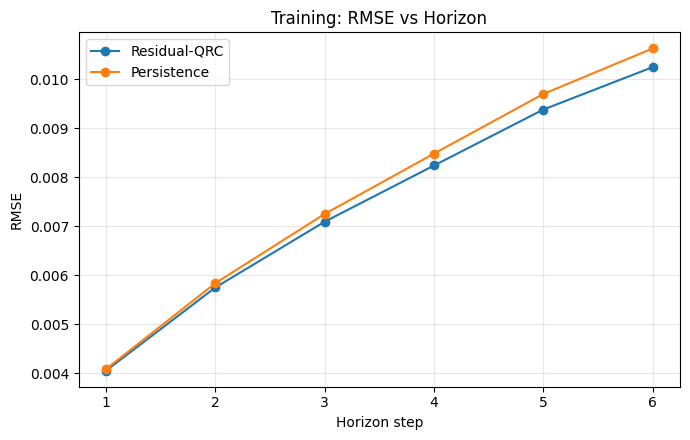

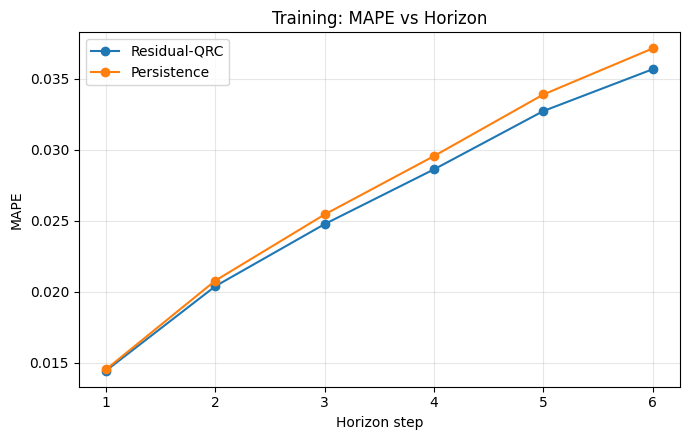

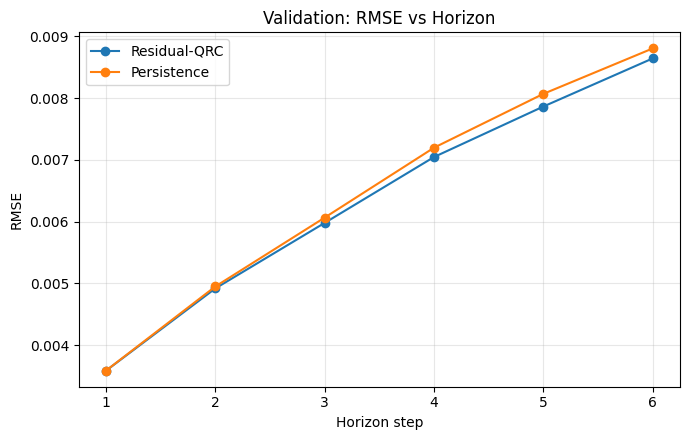

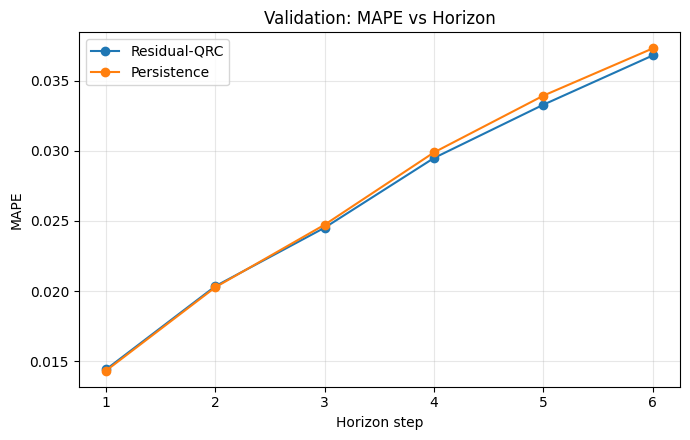

In [48]:
import numpy as np
import matplotlib.pyplot as plt

cfg.fb_strength = 0.0
cfg.ridge_alpha = 1.0

# Residual targets
last_tr, Ytr_res = residual_targets(Xtr_win, Ytr_win)
last_va, Yva_res = residual_targets(Xva_win, Yva_win)

Ytr_res_flat = Ytr_res.reshape(Ytr_res.shape[0], -1)
Yva_res_flat = Yva_res.reshape(Yva_res.shape[0], -1)

R_tr = compute_reservoir_features(Xtr_win, batch_size=64)
R_va = compute_reservoir_features(Xva_win, batch_size=64)

readout = Ridge(alpha=cfg.ridge_alpha, fit_intercept=True)
readout.fit(R_tr, Ytr_res_flat)

Ytr_res_hat = readout.predict(R_tr).astype(np.float32).reshape(Ytr_win.shape)
Ytr_hat = Ytr_res_hat + last_tr[:, None, :]
Yva_res_hat = readout.predict(R_va).astype(np.float32).reshape(Yva_win.shape)
Yva_hat = Yva_res_hat + last_va[:, None, :]

tr_pred_vol = invert_to_vol(Ytr_hat, pca=pca, scaler=scaler, eps=cfg.eps)
va_pred_vol = invert_to_vol(Yva_hat, pca=pca, scaler=scaler, eps=cfg.eps)

# --- helpers ---
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mape(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> float:
    return float(np.mean(np.abs(a - b) / (np.abs(b) + eps)))

def stepwise_metrics(pred_vol: np.ndarray, true_vol: np.ndarray, eps: float):
    """
    pred_vol, true_vol: (N, H, 224)
    returns arrays length H: rmse_by_h, mape_by_h
    """
    H = pred_vol.shape[1]
    rmses = np.zeros(H, dtype=np.float64)
    mapes = np.zeros(H, dtype=np.float64)
    for k in range(H):
        rmses[k] = rmse(pred_vol[:, k, :], true_vol[:, k, :])
        mapes[k] = mape(pred_vol[:, k, :], true_vol[:, k, :], eps=eps)
    return rmses, mapes

def plot_two_curves(h, y_rc, y_pers, ylabel, title):
    plt.figure(figsize=(7, 4.5))
    plt.plot(h, y_rc, marker="o", label="Residual-QRC")
    plt.plot(h, y_pers, marker="o", label="Persistence")
    plt.xlabel("Horizon step")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------------------------------------------------
# Assumes you already have these arrays from earlier cells:
#   Residual-RC (vol space):
#     tr_pred_vol, tr_true_vol, va_pred_vol, va_true_vol
#   Persistence (vol space):
#     tr_persist_vol, va_persist_vol
#   cfg.horizon, cfg.eps
# -------------------------------------------------------------------

H = cfg.horizon
h = np.arange(1, H + 1)

# Residual-RC stepwise
rc_tr_rmse, rc_tr_mape = stepwise_metrics(tr_pred_vol, tr_true_vol, eps=cfg.eps)
rc_va_rmse, rc_va_mape = stepwise_metrics(va_pred_vol, va_true_vol, eps=cfg.eps)

# Persistence stepwise
pers_tr_rmse, pers_tr_mape = stepwise_metrics(tr_persist_vol, tr_true_vol, eps=cfg.eps)
pers_va_rmse, pers_va_mape = stepwise_metrics(va_persist_vol, va_true_vol, eps=cfg.eps)

# 1) Training RMSE vs horizon
plot_two_curves(h, rc_tr_rmse, pers_tr_rmse, "RMSE", "Training: RMSE vs Horizon")

# 2) Training MAPE vs horizon
plot_two_curves(h, rc_tr_mape, pers_tr_mape, "MAPE", "Training: MAPE vs Horizon")

# 3) Validation RMSE vs horizon
plot_two_curves(h, rc_va_rmse, pers_va_rmse, "RMSE", "Validation: RMSE vs Horizon")

# 4) Validation MAPE vs horizon
plot_two_curves(h, rc_va_mape, pers_va_mape, "MAPE", "Validation: MAPE vs Horizon")

In [49]:
import numpy as np

cfg.fb_strength = 0.0
cfg.ridge_alpha = 1.0

# Residual targets
last_tr, Ytr_res = residual_targets(Xtr_win, Ytr_win)
last_va, Yva_res = residual_targets(Xva_win, Yva_win)

Ytr_res_flat = Ytr_res.reshape(Ytr_res.shape[0], -1)
Yva_res_flat = Yva_res.reshape(Yva_res.shape[0], -1)

R_tr = compute_reservoir_features(Xtr_win, batch_size=64)
R_va = compute_reservoir_features(Xva_win, batch_size=64)

readout = Ridge(alpha=cfg.ridge_alpha, fit_intercept=True)
readout.fit(R_tr, Ytr_res_flat)

Ytr_res_hat = readout.predict(R_tr).astype(np.float32).reshape(Ytr_win.shape)
Ytr_hat = Ytr_res_hat + last_tr[:, None, :]
Yva_res_hat = readout.predict(R_va).astype(np.float32).reshape(Yva_win.shape)
Yva_hat = Yva_res_hat + last_va[:, None, :]

tr_pred_vol = invert_to_vol(Ytr_hat, pca=pca, scaler=scaler, eps=cfg.eps)
va_pred_vol = invert_to_vol(Yva_hat, pca=pca, scaler=scaler, eps=cfg.eps)

def blend_with_persistence(Y_persist_pca, Y_rc_pca, alpha):
    return Y_persist_pca + alpha * (Y_rc_pca - Y_persist_pca)

alphas = np.linspace(0.0, 1.0, 101)

# assuming you already have:
#   Yva_persist  : (Nva,H,D) in PCA space
#   Yva_hat   : (Nva,H,D) in PCA space (your residual-RC prediction in PCA space)
#   Yva_win      : (Nva,H,D) true in PCA space

best = (1e9, None)
for a in alphas:
    Yblend = blend_with_persistence(Yva_persist, Yva_hat, a)
    pred_vol = invert_to_vol(Yblend, pca=pca, scaler=scaler, eps=cfg.eps)
    true_vol = invert_to_vol(Yva_win, pca=pca, scaler=scaler, eps=cfg.eps)
    v = rmse(pred_vol, true_vol)
    if v < best[0]:
        best = (v, a)

print("best val RMSE:", best[0], "alpha:", best[1])

best val RMSE: 0.0065675930968558316 alpha: 0.88


# Prediction over test data

In [ ]:
cfg.fb_strength = 0.0
cfg.ridge_alpha = 1.0

# # Residual targets
# last_tr, Ytr_res = residual_targets(Xtr_win, Ytr_win)
# last_va, Yva_res = residual_targets(Xva_win, Yva_win)

# Ytr_res_flat = Ytr_res.reshape(Ytr_res.shape[0], -1)
# Yva_res_flat = Yva_res.reshape(Yva_res.shape[0], -1)

# R_tr = compute_reservoir_features(Xtr_win, batch_size=64)
# R_va = compute_reservoir_features(Xva_win, batch_size=64)

# readout = Ridge(alpha=cfg.ridge_alpha, fit_intercept=True)
# readout.fit(R_tr, Ytr_res_flat)

# Old QRC residual model: predict next 6 rows and compare with test.xlsx

import numpy as np
import pandas as pd

required = ['cfg', 'Xva_win', 'compute_reservoir_features', 'readout', 'invert_to_vol', 'pca', 'scaler', 'feature_cols', 'df']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required objects from earlier QRC cells: {missing}')

# 1) Build one inference sample from the last validation window (30 days)
X_last = Z_val[-30:]  # (seq_len, pca_dim)
R_last = compute_reservoir_features(X_last[None, ...], batch_size=1)  # (1, f_dim)

# 2) Predict residuals for horizon=6 in PCA space
y_res_flat = readout.predict(R_last).astype(np.float32)  # (1, horizon*pca_dim)
Y_res_pred = y_res_flat.reshape(1, cfg.horizon, -1)      # (1, 6, pca_dim)

# Residual definition used earlier: Y = residual + last_observed
last_obs = X_last[-1][None, None, :]                     # (1,1,pca_dim)
Y_pred_pca = Y_res_pred + last_obs                       # (1,6,pca_dim)

# 3) Convert prediction back to volatility space
Y_pred_vol = invert_to_vol(Y_pred_pca, pca=pca, scaler=scaler, eps=cfg.eps)[0]  # (6, 224)

# 4) Build predicted dataframe in original HF column order
pred_next6_df = pd.DataFrame(Y_pred_vol, columns=feature_cols)

print('Old QRC predicted next 6 rows:')
display(pred_next6_df)

# 5) Load test.xlsx and compare
try:
    test_df = pd.read_excel('test.xlsx')
except Exception as e:
    raise RuntimeError(
        'Could not read test.xlsx. Install openpyxl in your environment, then rerun. '
        f'Original error: {e}'
    )

if len(test_df) < cfg.horizon:
    raise ValueError(f'test.xlsx has only {len(test_df)} rows; need at least {cfg.horizon}.')

actual6 = test_df.iloc[:cfg.horizon].copy()
missing_cols = [c for c in feature_cols if c not in actual6.columns]
if missing_cols:
    raise ValueError(f'test.xlsx is missing {len(missing_cols)} expected columns. Example: {missing_cols[:5]}')

pred_arr = pred_next6_df[feature_cols].to_numpy(dtype=np.float64)
true_arr = actual6[feature_cols].to_numpy(dtype=np.float64)

rmse_val = float(np.sqrt(np.mean((pred_arr - true_arr) ** 2)))
mape_val = float(100.0 * np.mean(np.abs(pred_arr - true_arr) / (np.abs(true_arr) + 1e-8)))

print('Old QRC next-6 vs test.xlsx')
print('RMSE:', rmse_val)
print('MAPE (%):', mape_val)

rmse_by_step = np.sqrt(np.mean((pred_arr - true_arr) ** 2, axis=1))
mape_by_step = 100.0 * np.mean(np.abs(pred_arr - true_arr) / (np.abs(true_arr) + 1e-8), axis=1)

step_metrics = pd.DataFrame({
    'step_ahead': np.arange(1, cfg.horizon + 1),
    'rmse': rmse_by_step,
    'mape_pct': mape_by_step,
})

print('Per-step metrics:')
display(step_metrics)

Old QRC predicted next 6 rows:


,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,Tenor : 10; Maturity : 0.0833333333333333,...,Tenor : 5; Maturity : 30,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30
0,0.023616,0.031812,0.033818,0.035452,0.036009,0.035447,0.035080,0.034771,0.035049,0.034451,...,0.343358,0.341510,0.343785,0.337453,0.339013,0.335953,0.359118,0.374447,0.354636,0.344360
1,0.023679,0.031931,0.033938,0.035561,0.036115,0.035539,0.035153,0.034838,0.035106,0.034497,...,0.342647,0.340803,0.343105,0.336765,0.338347,0.335305,0.358536,0.373883,0.354065,0.343794
2,0.023560,0.031867,0.033882,0.035501,0.036061,0.035480,0.035086,0.034770,0.035032,0.034421,...,0.341589,0.339743,0.342062,0.335709,0.337303,0.334268,0.357576,0.372936,0.353199,0.343015
3,0.023483,0.031818,0.033837,0.035451,0.036016,0.035434,0.035034,0.034717,0.034976,0.034363,...,0.340820,0.338977,0.341317,0.334954,0.336566,0.333541,0.356914,0.372291,0.352562,0.342428
4,0.023404,0.031774,0.033799,0.035413,0.035988,0.035404,0.035000,0.034683,0.034938,0.034322,...,0.339799,0.337953,0.340310,0.333945,0.335579,0.332580,0.355949,0.371291,0.351714,0.341692
5,0.023247,0.031616,0.033656,0.035288,0.035884,0.035316,0.034929,0.034621,0.034883,0.034274,...,0.339472,0.337628,0.339999,0.333635,0.335292,0.332317,0.355652,0.370975,0.351407,0.341433


Old QRC next-6 vs test.xlsx
RMSE: 0.013547774056018976
MAPE (%): 5.794262433918354
Per-step metrics:


,step_ahead,rmse,mape_pct
0,1,0.002558,1.208473
1,2,0.007086,3.766278
2,3,0.009309,4.836718
3,4,0.013231,6.639721
4,5,0.021074,9.724922
5,6,0.018402,8.589463


In [57]:
# Persistence model: predict next 6 rows and compare with test.xlsx

import numpy as np
import pandas as pd

required = ['cfg', 'invert_to_vol', 'pca', 'scaler', 'df']
missing = [v for v in required if v not in globals()]
if missing:
    raise RuntimeError(f'Missing required objects from earlier cells: {missing}')

# Use last 30 days from validation tail in PCA space
if 'Z_val' in globals():
    X_last = Z_val[-cfg.seq_len:]  # (seq_len, pca_dim)
elif 'Xva_win' in globals():
    X_last = Xva_win[-1]           # (seq_len, pca_dim)
else:
    raise RuntimeError('Need either Z_val or Xva_win defined from previous QRC preprocessing cells.')

# Persistence forecast in PCA space: repeat last observed point for all 6 steps
last_obs = X_last[-1]  # (pca_dim,)
Y_persist_pca = np.repeat(last_obs[None, None, :], cfg.horizon, axis=1).astype(np.float32)  # (1,6,D)

# Convert to volatility space
Y_persist_vol = invert_to_vol(Y_persist_pca, pca=pca, scaler=scaler, eps=cfg.eps)[0]  # (6,224)

feature_cols = [c for c in df.columns if c != 'Date']

persist_next6_df = pd.DataFrame(Y_persist_vol, columns=feature_cols)

print('Persistence predicted next 6 rows:')
display(persist_next6_df)

# Compare against test.xlsx
try:
    test_df = pd.read_excel('test.xlsx')
except Exception as e:
    raise RuntimeError(
        'Could not read test.xlsx. Install openpyxl in your environment, then rerun. '
        f'Original error: {e}'
    )

if len(test_df) < cfg.horizon:
    raise ValueError(f'test.xlsx has only {len(test_df)} rows; need at least {cfg.horizon}.')

actual6 = test_df.iloc[:cfg.horizon].copy()
missing_cols = [c for c in feature_cols if c not in actual6.columns]
if missing_cols:
    raise ValueError(f'test.xlsx is missing {len(missing_cols)} expected columns. Example: {missing_cols[:5]}')

pred_arr = persist_next6_df[feature_cols].to_numpy(dtype=np.float64)
true_arr = actual6[feature_cols].to_numpy(dtype=np.float64)

rmse_val = float(np.sqrt(np.mean((pred_arr - true_arr) ** 2)))
mape_val = float(100.0 * np.mean(np.abs(pred_arr - true_arr) / (np.abs(true_arr) + 1e-8)))

print('Persistence next-6 vs test.xlsx')
print('RMSE:', rmse_val)
print('MAPE (%):', mape_val)

rmse_by_step = np.sqrt(np.mean((pred_arr - true_arr) ** 2, axis=1))
mape_by_step = 100.0 * np.mean(np.abs(pred_arr - true_arr) / (np.abs(true_arr) + 1e-8), axis=1)

step_metrics = pd.DataFrame({
    'step_ahead': np.arange(1, cfg.horizon + 1),
    'rmse': rmse_by_step,
    'mape_pct': mape_by_step,
})

print('Per-step metrics:')
display(step_metrics)



Persistence predicted next 6 rows:


,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,Tenor : 10; Maturity : 0.0833333333333333,...,Tenor : 5; Maturity : 30,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30
0,0.023542,0.031677,0.033678,0.035316,0.035875,0.035327,0.034974,0.034672,0.034959,0.034372,...,0.343968,0.342117,0.344366,0.338039,0.339575,0.336494,0.359618,0.374937,0.355129,0.344858
1,0.023542,0.031677,0.033678,0.035316,0.035875,0.035327,0.034974,0.034672,0.034959,0.034372,...,0.343968,0.342117,0.344366,0.338039,0.339575,0.336494,0.359618,0.374937,0.355129,0.344858
2,0.023542,0.031677,0.033678,0.035316,0.035875,0.035327,0.034974,0.034672,0.034959,0.034372,...,0.343968,0.342117,0.344366,0.338039,0.339575,0.336494,0.359618,0.374937,0.355129,0.344858
3,0.023542,0.031677,0.033678,0.035316,0.035875,0.035327,0.034974,0.034672,0.034959,0.034372,...,0.343968,0.342117,0.344366,0.338039,0.339575,0.336494,0.359618,0.374937,0.355129,0.344858
4,0.023542,0.031677,0.033678,0.035316,0.035875,0.035327,0.034974,0.034672,0.034959,0.034372,...,0.343968,0.342117,0.344366,0.338039,0.339575,0.336494,0.359618,0.374937,0.355129,0.344858
5,0.023542,0.031677,0.033678,0.035316,0.035875,0.035327,0.034974,0.034672,0.034959,0.034372,...,0.343968,0.342117,0.344366,0.338039,0.339575,0.336494,0.359618,0.374937,0.355129,0.344858


Persistence next-6 vs test.xlsx
RMSE: 0.012605256389860889
MAPE (%): 5.623593233900503
Per-step metrics:


,step_ahead,rmse,mape_pct
0,1,0.002468,1.264063
1,2,0.006927,3.818087
2,3,0.008702,4.711851
3,4,0.012272,6.391294
4,5,0.019677,9.374138
5,6,0.016904,8.182127
